In [1]:
import xrft
import xarray as xr
from xgcm.grid import Grid
from dask.diagnostics import ProgressBar

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

In [2]:
def open_llc4320_velocity_data(chunks='auto', time_range=None):
    
    ds_SSU = xr.open_dataset(
        "gs://pangeo-ecco-llc4320/ssu", 
        engine="zarr", 
        storage_options={'requester_pays': True}, 
        chunks=chunks, 
        inline_array=True,
        consolidated=True, 
    )
    
    ds_SSV = xr.open_dataset(
        "gs://pangeo-ecco-llc4320/ssv", 
        engine="zarr", 
        storage_options={'requester_pays': True}, 
        chunks=chunks, 
        inline_array=True,
        consolidated=True, 
    )
    
    # Open grid data
    ds_grid = xr.open_dataset(
        "gs://pangeo-ecco-llc4320/grid", 
        engine="zarr", 
        storage_options={'requester_pays': True}, 
        chunks=chunks, 
        inline_array=True,
        consolidated=True, 
    )
    
    coords_to_keep = ['XC', 'YC','XG','YG', 'dxC', 'dyC', 'dxG', 'dyG', 'rAz', 'rA', 'Depth']
    ds_grid = ds_grid.reset_coords()[coords_to_keep]
    
    ds = xr.merge([ds_SSU, ds_SSV, ds_grid])
        
    if time_range is not None:
        ds = ds.isel(time=time_range)
        
    ds = ds.chunk(chunks)
    
    return ds, ds_grid
    

In [3]:
ds, ds_grid = open_llc4320_velocity_data(chunks={})

In [4]:
grid = Grid(ds_grid, periodic=False)

In [5]:
t_width=200
i_extent = slice(0,540)
j_extent = slice(3780,4320)
ds_subset = ds.isel(time=slice(2736-t_width,2736+t_width)).sel(face=1
                                ).isel(j_g=j_extent).isel(j=j_extent).isel(i_g=i_extent).isel(i=i_extent)

In [6]:
u_subset = ds_subset.U.rename({"i_g": "i"})
v_subset = ds_subset.V.rename({"j_g": "j"})

In [7]:
u_subset

<xarray.DataArray 'U' (time: 400, j: 540, i: 540)> Size: 467MB
dask.array<getitem, shape=(400, 540, 540), dtype=float32, chunksize=(1, 540, 540), chunktype=numpy.ndarray>
Coordinates:
    face     int64 8B 1
  * i        (i) int64 4kB 0 1 2 3 4 5 6 7 8 ... 532 533 534 535 536 537 538 539
  * j        (j) int64 4kB 3780 3781 3782 3783 3784 ... 4315 4316 4317 4318 4319
  * time     (time) datetime64[ns] 3kB 2011-12-27T16:00:00 ... 2012-01-13T07:...

In [8]:
with ProgressBar():
    u2_psa = xrft.power_spectrum(u_subset.load(), dim=['i','j','time'],window=True,window_correction=True).compute()
    v2_psa = xrft.power_spectrum(v_subset.load(), dim=['i','j','time'],window=True,window_correction=True).compute()
vel_psa = (u2_psa + v2_psa)*0.5

[########################################] | 100% Completed | 100.57 s


/srv/conda/envs/notebook/lib/python3.12/site-packages/xrft/xrft.py:47: FutureWarning: Please provide the name of window adhering to scipy.signal.windows. The boolean option will be deprecated in future releases.
  warnings.warn(
/srv/conda/envs/notebook/lib/python3.12/site-packages/xrft/xrft.py:47: FutureWarning: Please provide the name of window adhering to scipy.signal.windows. The boolean option will be deprecated in future releases.
  warnings.warn(


[########################################] | 100% Completed | 101.67 s


/srv/conda/envs/notebook/lib/python3.12/site-packages/xrft/xrft.py:47: FutureWarning: Please provide the name of window adhering to scipy.signal.windows. The boolean option will be deprecated in future releases.
  warnings.warn(
/srv/conda/envs/notebook/lib/python3.12/site-packages/xrft/xrft.py:47: FutureWarning: Please provide the name of window adhering to scipy.signal.windows. The boolean option will be deprecated in future releases.
  warnings.warn(


In [9]:
def azimuthal_avg(k, l, f, N, nfactor):
    """
    Takes the azimuthal average of a given field.
    """
    k = k.values; l = l.values
    kk, ll = np.meshgrid(k, l)
    K = np.sqrt(kk**2 + ll**2)
    nbins = int(N/nfactor)
    if k.max() > l.max():
        ki = np.linspace(0., l.max(), nbins)
    else:
        ki = np.linspace(0., k.max(), nbins)

    kidx = np.digitize(np.ravel(K), ki)
    area = np.bincount(kidx)

    kr = np.bincount(kidx, weights=K.ravel()) / area

    if f.ndim == 2:
        iso_f = np.ma.masked_invalid(np.bincount(kidx,
                                    weights=f.data.ravel())
                                    / area) * kr
    else:
        raise ValueError('The data has too many or few dimensions. '
                        'The input should only have the two dimensions '
                        'to take the azimuthal averaging over.')

    return kr, iso_f

def iso_spec(ds):
    
    #Zlen = len(ds.Z)
    klen = len(ds.freq_i)
    omegalen = len(ds.freq_time)
    
    nfactor = 4. 
    ds_iso = np.zeros([omegalen ,  int(klen/nfactor+1)])

    for j in range(0,omegalen):
            kr, ds_iso[j,:] = azimuthal_avg(ds.freq_i, ds.freq_j, ds.isel(freq_time=j), 
                            len(ds.freq_i), nfactor)
    kr[0] = 0.
    ds_iso_xr = xr.DataArray(ds_iso, coords={'freq_time':ds.freq_time.values, 'kr':kr }, 
                             dims=['freq_time','kr'])
    
    return ds_iso_xr

In [10]:
ps_isoa = iso_spec(vel_psa)

/tmp/ipykernel_560/561257206.py:17: RuntimeWarning: invalid value encountered in divide
  kr = np.bincount(kidx, weights=K.ravel()) / area
/tmp/ipykernel_560/561257206.py:20: RuntimeWarning: invalid value encountered in divide
  iso_f = np.ma.masked_invalid(np.bincount(kidx,


In [11]:
ps_isoa

<xarray.DataArray (freq_time: 400, kr: 136)> Size: 435kB
array([[       nan, 0.03446653, 0.00527118, ..., 0.00066401, 0.00066617,
        0.00035618],
       [       nan, 0.02210671, 0.00652019, ..., 0.00065345, 0.00069099,
        0.00036114],
       [       nan, 0.01412031, 0.00626727, ..., 0.00064652, 0.00065746,
        0.00036596],
       ...,
       [       nan, 0.0095215 , 0.00297864, ..., 0.00068023, 0.00064079,
        0.00035831],
       [       nan, 0.01412031, 0.00626727, ..., 0.00064652, 0.00065746,
        0.00036596],
       [       nan, 0.02210671, 0.00652019, ..., 0.00065345, 0.00069099,
        0.00036114]], shape=(400, 136))
Coordinates:
  * freq_time  (freq_time) float64 3kB -0.0001389 -0.0001382 ... 0.0001382
  * kr         (kr) float64 1kB 0.0 0.002515 0.005728 ... 0.4925 0.4963 0.5612

/tmp/ipykernel_560/1285284960.py:8: UserWarning: Log scale: values of z <= 0 have been masked
  plt.contourf(kr,omega,np.abs(omega)*kr*positive_ps,norm=LogNorm(), cmap='magma',extend='both')


(0.002, 0.5)

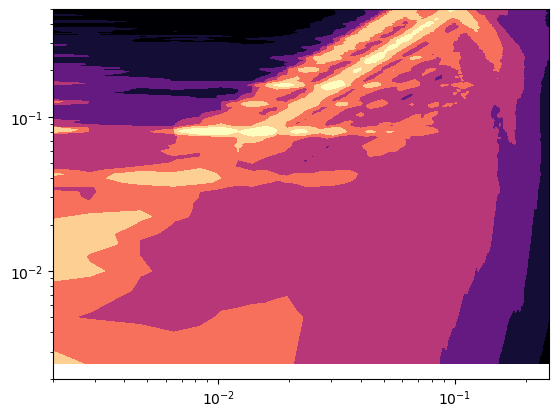

In [15]:
positive_ps = ps_isoa.isel(freq_time=slice(200,400))
kr = positive_ps.kr/2
omega = positive_ps.freq_time*3600

lev_exp = np.linspace(-4,1,16)
lev = np.power(10, lev_exp)[0:15]

plt.contourf(kr,omega,np.abs(omega)*kr*positive_ps,norm=LogNorm(), cmap='magma',extend='both')
plt.xscale('log')
plt.yscale('log')
plt.xlim([0.002, 0.25])
plt.ylim([0.002, 0.5])

In [30]:
omega

<xarray.DataArray 'freq_time' (freq_time: 400)> Size: 3kB
array([0.     , 0.00125, 0.0025 , 0.00375, 0.005  , 0.00625, 0.0075 ,
       0.00875, 0.01   , 0.01125, 0.0125 , 0.01375, 0.015  , 0.01625,
       0.0175 , 0.01875, 0.02   , 0.02125, 0.0225 , 0.02375, 0.025  ,
       0.02625, 0.0275 , 0.02875, 0.03   , 0.03125, 0.0325 , 0.03375,
       0.035  , 0.03625, 0.0375 , 0.03875, 0.04   , 0.04125, 0.0425 ,
       0.04375, 0.045  , 0.04625, 0.0475 , 0.04875, 0.05   , 0.05125,
       0.0525 , 0.05375, 0.055  , 0.05625, 0.0575 , 0.05875, 0.06   ,
       0.06125, 0.0625 , 0.06375, 0.065  , 0.06625, 0.0675 , 0.06875,
       0.07   , 0.07125, 0.0725 , 0.07375, 0.075  , 0.07625, 0.0775 ,
       0.07875, 0.08   , 0.08125, 0.0825 , 0.08375, 0.085  , 0.08625,
       0.0875 , 0.08875, 0.09   , 0.09125, 0.0925 , 0.09375, 0.095  ,
       0.09625, 0.0975 , 0.09875, 0.1    , 0.10125, 0.1025 , 0.10375,
       0.105  , 0.10625, 0.1075 , 0.10875, 0.11   , 0.11125, 0.1125 ,
       0.11375, 0.115  , 0.11625, 0.1175 , 0.11875, 0.12   , 0.12125,
       0.1225 , 0.12375, 0.125  , 0.12625, 0.1275 , 0.12875, 0.13   ,
       0.13125, 0.1325 , 0.13375, 0.135  , 0.13625, 0.1375 , 0.13875,
       0.14   , 0.14125, 0.1425 , 0.14375, 0.145  , 0.14625, 0.1475 ,
       0.14875, 0.15   , 0.15125, 0.1525 , 0.15375, 0.155  , 0.15625,
       0.1575 , 0.15875, 0.16   , 0.16125, 0.1625 , 0.16375, 0.165  ,
       0.16625, 0.1675 , 0.16875, 0.17   , 0.17125, 0.1725 , 0.17375,
...
       0.3325 , 0.33375, 0.335  , 0.33625, 0.3375 , 0.33875, 0.34   ,
       0.34125, 0.3425 , 0.34375, 0.345  , 0.34625, 0.3475 , 0.34875,
       0.35   , 0.35125, 0.3525 , 0.35375, 0.355  , 0.35625, 0.3575 ,
       0.35875, 0.36   , 0.36125, 0.3625 , 0.36375, 0.365  , 0.36625,
       0.3675 , 0.36875, 0.37   , 0.37125, 0.3725 , 0.37375, 0.375  ,
       0.37625, 0.3775 , 0.37875, 0.38   , 0.38125, 0.3825 , 0.38375,
       0.385  , 0.38625, 0.3875 , 0.38875, 0.39   , 0.39125, 0.3925 ,
       0.39375, 0.395  , 0.39625, 0.3975 , 0.39875, 0.4    , 0.40125,
       0.4025 , 0.40375, 0.405  , 0.40625, 0.4075 , 0.40875, 0.41   ,
       0.41125, 0.4125 , 0.41375, 0.415  , 0.41625, 0.4175 , 0.41875,
       0.42   , 0.42125, 0.4225 , 0.42375, 0.425  , 0.42625, 0.4275 ,
       0.42875, 0.43   , 0.43125, 0.4325 , 0.43375, 0.435  , 0.43625,
       0.4375 , 0.43875, 0.44   , 0.44125, 0.4425 , 0.44375, 0.445  ,
       0.44625, 0.4475 , 0.44875, 0.45   , 0.45125, 0.4525 , 0.45375,
       0.455  , 0.45625, 0.4575 , 0.45875, 0.46   , 0.46125, 0.4625 ,
       0.46375, 0.465  , 0.46625, 0.4675 , 0.46875, 0.47   , 0.47125,
       0.4725 , 0.47375, 0.475  , 0.47625, 0.4775 , 0.47875, 0.48   ,
       0.48125, 0.4825 , 0.48375, 0.485  , 0.48625, 0.4875 , 0.48875,
       0.49   , 0.49125, 0.4925 , 0.49375, 0.495  , 0.49625, 0.4975 ,
       0.49875])
Coordinates:
  * freq_time  (freq_time) float64 3kB 0.0 3.472e-07 ... 0.0001382 0.0001385

In [85]:
1/200

0.005